(mmm_media_inflation)=

# Why and how to account for media inflation in your media mix model (MMM)

*Nominal spend can change meaning over time. This notebook shows how to choose a stable media input, adjust spend when necessary, and assess the effect on attribution.*

Media inflation occurs when the cost of buying media increases over time. For example, if CPM (cost per thousand impressions) rises faster than a budget, the same nominal spend buys fewer impressions. An MMM fitted directly on that spend may then confuse changes in media delivery with changes in baseline demand.

The practical goal is simple: give the model a media input whose units have a consistent interpretation across the modelling period. We first show why this matters with simulated data, then compare an MMM fitted on nominal spend with one fitted on spend converted to today's dollars.

```{note}
**Prerequisites.** You should have worked through {ref}`mmm_quickstart` or {ref}`mmm_example` and be able to build and fit an `MMM`. This notebook focuses on media-unit preprocessing rather than the general MMM workflow.

**Scope.** The example uses one paid channel and simulated data with a known reference truth. The same reasoning applies to impressions, GRPs (gross rating points), and other measures of media delivery. In production, each channel may need its own media-cost index because auction inflation differs across formats.
```


## Setup

In [1]:
import arviz as az
import graphviz as gr
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pytensor.xtensor import as_xtensor

from pymc_marketing.mmm import GeometricAdstock, LinearTrend, LogisticSaturation
from pymc_marketing.mmm.additive_effect import LinearTrendEffect
from pymc_marketing.mmm.mmm import MMM

az.style.use("arviz-darkgrid")

FIG_WIDTH = 12
FIG_HEIGHT = 7
plt.rcParams["figure.figsize"] = [FIG_WIDTH, FIG_HEIGHT]
plt.rcParams["figure.dpi"] = 100

LEGEND_KW = {
    "frameon": True,
    "facecolor": "white",
    "framealpha": 0.8,
    "edgecolor": "0.7",
}

COLOR_CPM = "#E76F51"
COLOR_SPEND = "#2A9D8F"
COLOR_IMPRESSIONS = "#E9C46A"
COLOR_Y = "#1D3557"
COLOR_MEDIA = "#264653"
COLOR_TREND = "#9B5DE5"

CHANNEL = "paid_social"
ANNUAL_CPM_INFLATION = 0.08
ANNUAL_SPEND_GROWTH = 0.03
WEEKS_PER_YEAR = 52.0
HIGH_DEFLATION_RATE = 0.16

%config InlineBackend.figure_format = "retina"


def style_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.grid(True, which="major", axis="x", linestyle="-", alpha=0.35)
    ax.grid(True, which="minor", axis="x", linestyle=":", alpha=0.2)

In [2]:
RANDOM_SEED = sum(map(ord, "inflation"))
rng = np.random.default_rng(seed=RANDOM_SEED)

FIT_KWARGS = {
    "nuts_sampler": "nutpie",
    "target_accept": 0.9,
    "chains": 4,
    "draws": 500,
    "tune": 500,
    "random_seed": RANDOM_SEED,
}

## What media inflation changes

Saturation maps the media input to an effective dose before it enters the outcome model. That mapping assumes a **time-invariant** relationship between the input and advertising exposure. In practice, delivery is linked to spend through a cost per unit:

$$
\text{delivery}_t \propto \frac{\text{spend}_t}{\text{cost per unit}_t}.
$$

For paid social, cost per unit is CPM; for television, it may be cost per GRP. How spend and cost per unit move together determines what a spend-based MMM actually sees:

- **Stable cost per unit.** Spend tracks delivery; a fixed saturation curve is appropriate.
- **Constant nominal spend, rising cost per unit.** Budget is flat in currency terms but delivery falls. The model still sees a steady dose and may overstate past effectiveness or misattribute the shortfall to trend, seasonality, or other channels.
- **Constant delivery (real-terms budget), rising cost per unit.** Nominal spend rises to hold impressions or GRPs flat. The model sees a growing dose where exposure is unchanged and can over-credit the channel.
- **Spend rising faster than media inflation.** Delivery grows, but part of the nominal spend increase is price, not volume. Saturation treats every extra dollar as extra dose, which can inflate estimated returns.
- **Spend rising slower than media inflation (or falling).** Nominal spend can still increase while delivery declines. The model may read a healthy budget trajectory when exposure is actually shrinking.

In each drifting case, a model with **time-invariant** saturation cannot separate “the dollar buys less (or more) than it used to” from “the channel became less (or more) effective.” Without time-varying parameters—or deflating spend by a cost index—the fit compensates by shifting attribution across media, baseline, and trend rather than isolating the unit-cost change.

Spend is not inherently the wrong input. When the cost per unit is stable, spend is proportional to delivery and a spend-based MMM can estimate a well-defined total effect of budget. What breaks is narrower: **the spend-to-delivery map drifts while saturation treats each dollar as the same dose.** A model that sees only nominal spend cannot distinguish that unit change from a change in media effectiveness or baseline demand.

Many teams fit native delivery units such as impressions or GRPs when those series are stable and well measured, then use {ref}`mmm_cost_per_unit` for currency reporting. Others fit spend directly when the spend-to-delivery map is stable, or reconstruct delivery from spend and a smooth cost-per-unit series before fitting. That unit choice depends on your estimand, data quality, and how costs move over time; see {ref}`mmm_cost_per_unit` for a broader discussion. This notebook focuses on the spend-only path when delivery is unavailable: deflate spend with an external media-cost index, then test how sensitive attribution is to the assumed rate. A decision table with common workflows appears in the summary.

The simulated example is deliberately small: one market, one paid channel, and 156 weeks. Media cost is exogenous in the data-generating process; targeting feedback, demand-driven pricing, and causal confounding are out of scope here. Its known reference truth lets us check whether an MMM recovers the direction of media and trend contributions.

We use a constant intercept, mild yearly seasonality, and a few-changepoint {class}`~pymc_marketing.mmm.linear_trend.LinearTrend` in every fit. The model specification stays fixed so the comparison isolates the effect of changing the units of $X$.

The diagram below summarizes the data-generating structure for the simulation.


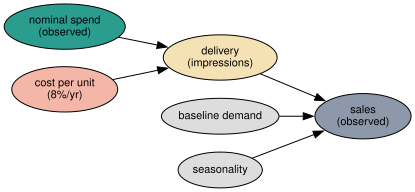

In [3]:
g = gr.Digraph(graph_attr={"rankdir": "LR"})
g.attr("node", fontname="Helvetica", fontsize="11")

g.node("spend", "nominal spend\n(observed)", style="filled", fillcolor="#2A9D8F")
g.node(
    "cost",
    f"cost per unit\n({ANNUAL_CPM_INFLATION:.0%}/yr)",
    style="filled",
    fillcolor="#E76F5180",
)
g.node("delivery", "delivery\n(impressions)", style="filled", fillcolor="#E9C46A80")
g.node("baseline", "baseline demand", style="filled", fillcolor="#dddddd")
g.node("season", "seasonality", style="filled", fillcolor="#dddddd")
g.node("y", "sales\n(observed)", style="filled", fillcolor="#1D355780")

with g.subgraph() as inputs:
    inputs.attr(rank="same")
    inputs.node("spend")
    inputs.node("cost")

g.edge("spend", "delivery")
g.edge("cost", "delivery")
g.edge("delivery", "y")
g.edge("baseline", "y")
g.edge("season", "y")
g

**Caption:** Data-generating DAG: nominal spend and cost per unit determine delivery; delivery, baseline demand, and seasonality determine sales. Spend-only analysts observe spend and sales; cost and delivery are latent.

The next cell generates this example. Nominal spend and cost per unit determine impressions. The analyst receives **date, nominal spend, and sales**; impressions and CPM are simulated reference columns for validation only.


In [4]:
DGP_L_MAX = 8
DGP_ADSTOCK_ALPHA = 0.4
DGP_SATURATION_LAM = 2.5
DGP_MEDIA_BETA = 1_200.0
_dgp_adstock = GeometricAdstock(l_max=DGP_L_MAX)
_dgp_saturation = LogisticSaturation()

n_weeks = 156
dates = pd.date_range("2023-01-02", periods=n_weeks, freq="W-MON")
years_elapsed = np.arange(n_weeks) / WEEKS_PER_YEAR

flight = 0.45 + 0.55 * ((np.arange(n_weeks) % 10) < 6).astype(float)
cpm_factor = (1.0 + ANNUAL_CPM_INFLATION) ** years_elapsed
spend_factor = (1.0 + ANNUAL_SPEND_GROWTH) ** years_elapsed

cpm = 10.0 * cpm_factor
spend = 5_000.0 * spend_factor * flight * (1.0 + 0.05 * rng.normal(size=n_weeks))
spend = np.clip(spend, 1.0, None)
impressions = spend * 1_000.0 / cpm

imp_scaled = impressions / impressions.max()
time_dim = "time"
adstocked = _dgp_adstock.function(
    as_xtensor(imp_scaled, dims=(time_dim,)),
    alpha=DGP_ADSTOCK_ALPHA,
    dim=time_dim,
).eval()
media_true = _dgp_saturation.function(
    as_xtensor(adstocked, dims=(time_dim,)),
    lam=DGP_SATURATION_LAM,
    beta=DGP_MEDIA_BETA,
    dim=time_dim,
).eval()

intercept_true = 2_000.0
season = 80.0 * np.sin(2.0 * np.pi * dates.dayofyear.to_numpy() / 365.25)
y = intercept_true + media_true + season + rng.normal(0.0, 40.0, size=n_weeks)

df = pd.DataFrame(
    {
        "date": dates,
        CHANNEL: spend,
        "impressions": impressions,
        "cpm": cpm,
        "y": y,
        "media_true": media_true,
    }
)

Index nominal spend and impressions to week 1 (= 100) so the divergence between budget growth and delivery is easy to see.

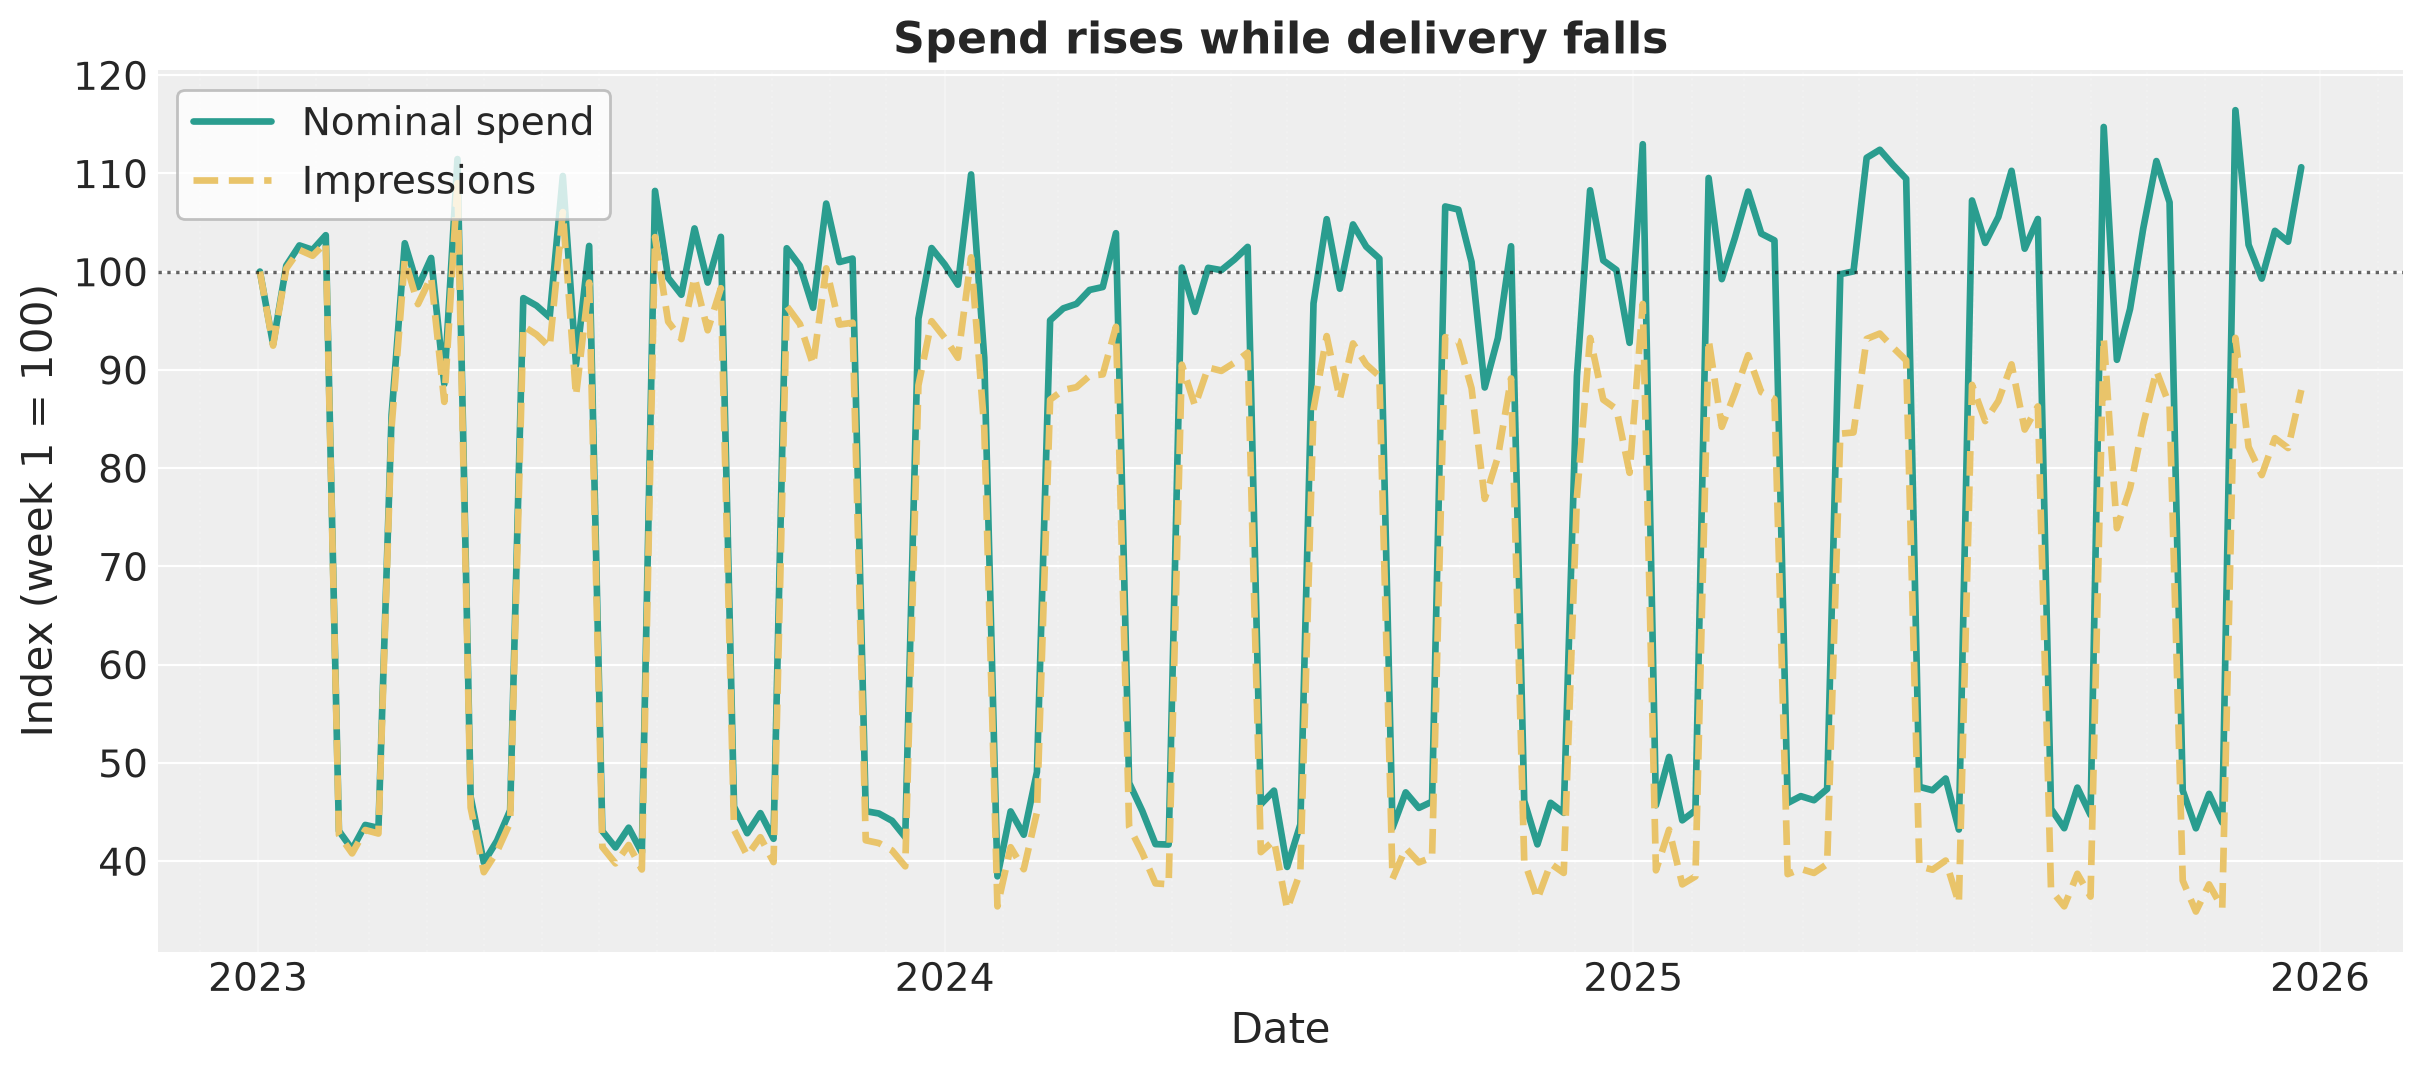

In [5]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT * 0.75))
spend_index = 100.0 * df[CHANNEL] / df[CHANNEL].iloc[0]
imp_index = 100.0 * df["impressions"] / df["impressions"].iloc[0]
ax.plot(
    df["date"], spend_index, color=COLOR_SPEND, linewidth=2.4, label="Nominal spend"
)
ax.plot(
    df["date"],
    imp_index,
    color=COLOR_IMPRESSIONS,
    linewidth=2.4,
    linestyle="--",
    label="Impressions",
)
ax.axhline(100.0, color="black", linestyle=":", linewidth=1.2, alpha=0.6)
ax.set_ylabel("Index (week 1 = 100)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", **LEGEND_KW)
ax.set_title("Spend rises while delivery falls", fontsize=16, fontweight="bold")
style_date_axis(ax)
plt.show()

**Caption:** Nominal paid-social spend and impressions indexed to week 1 (= 100). Spend increases with budget growth, while impressions decrease because CPM increases faster than spend.


The four weekly series below show CPM, spend, impressions, and sales together.

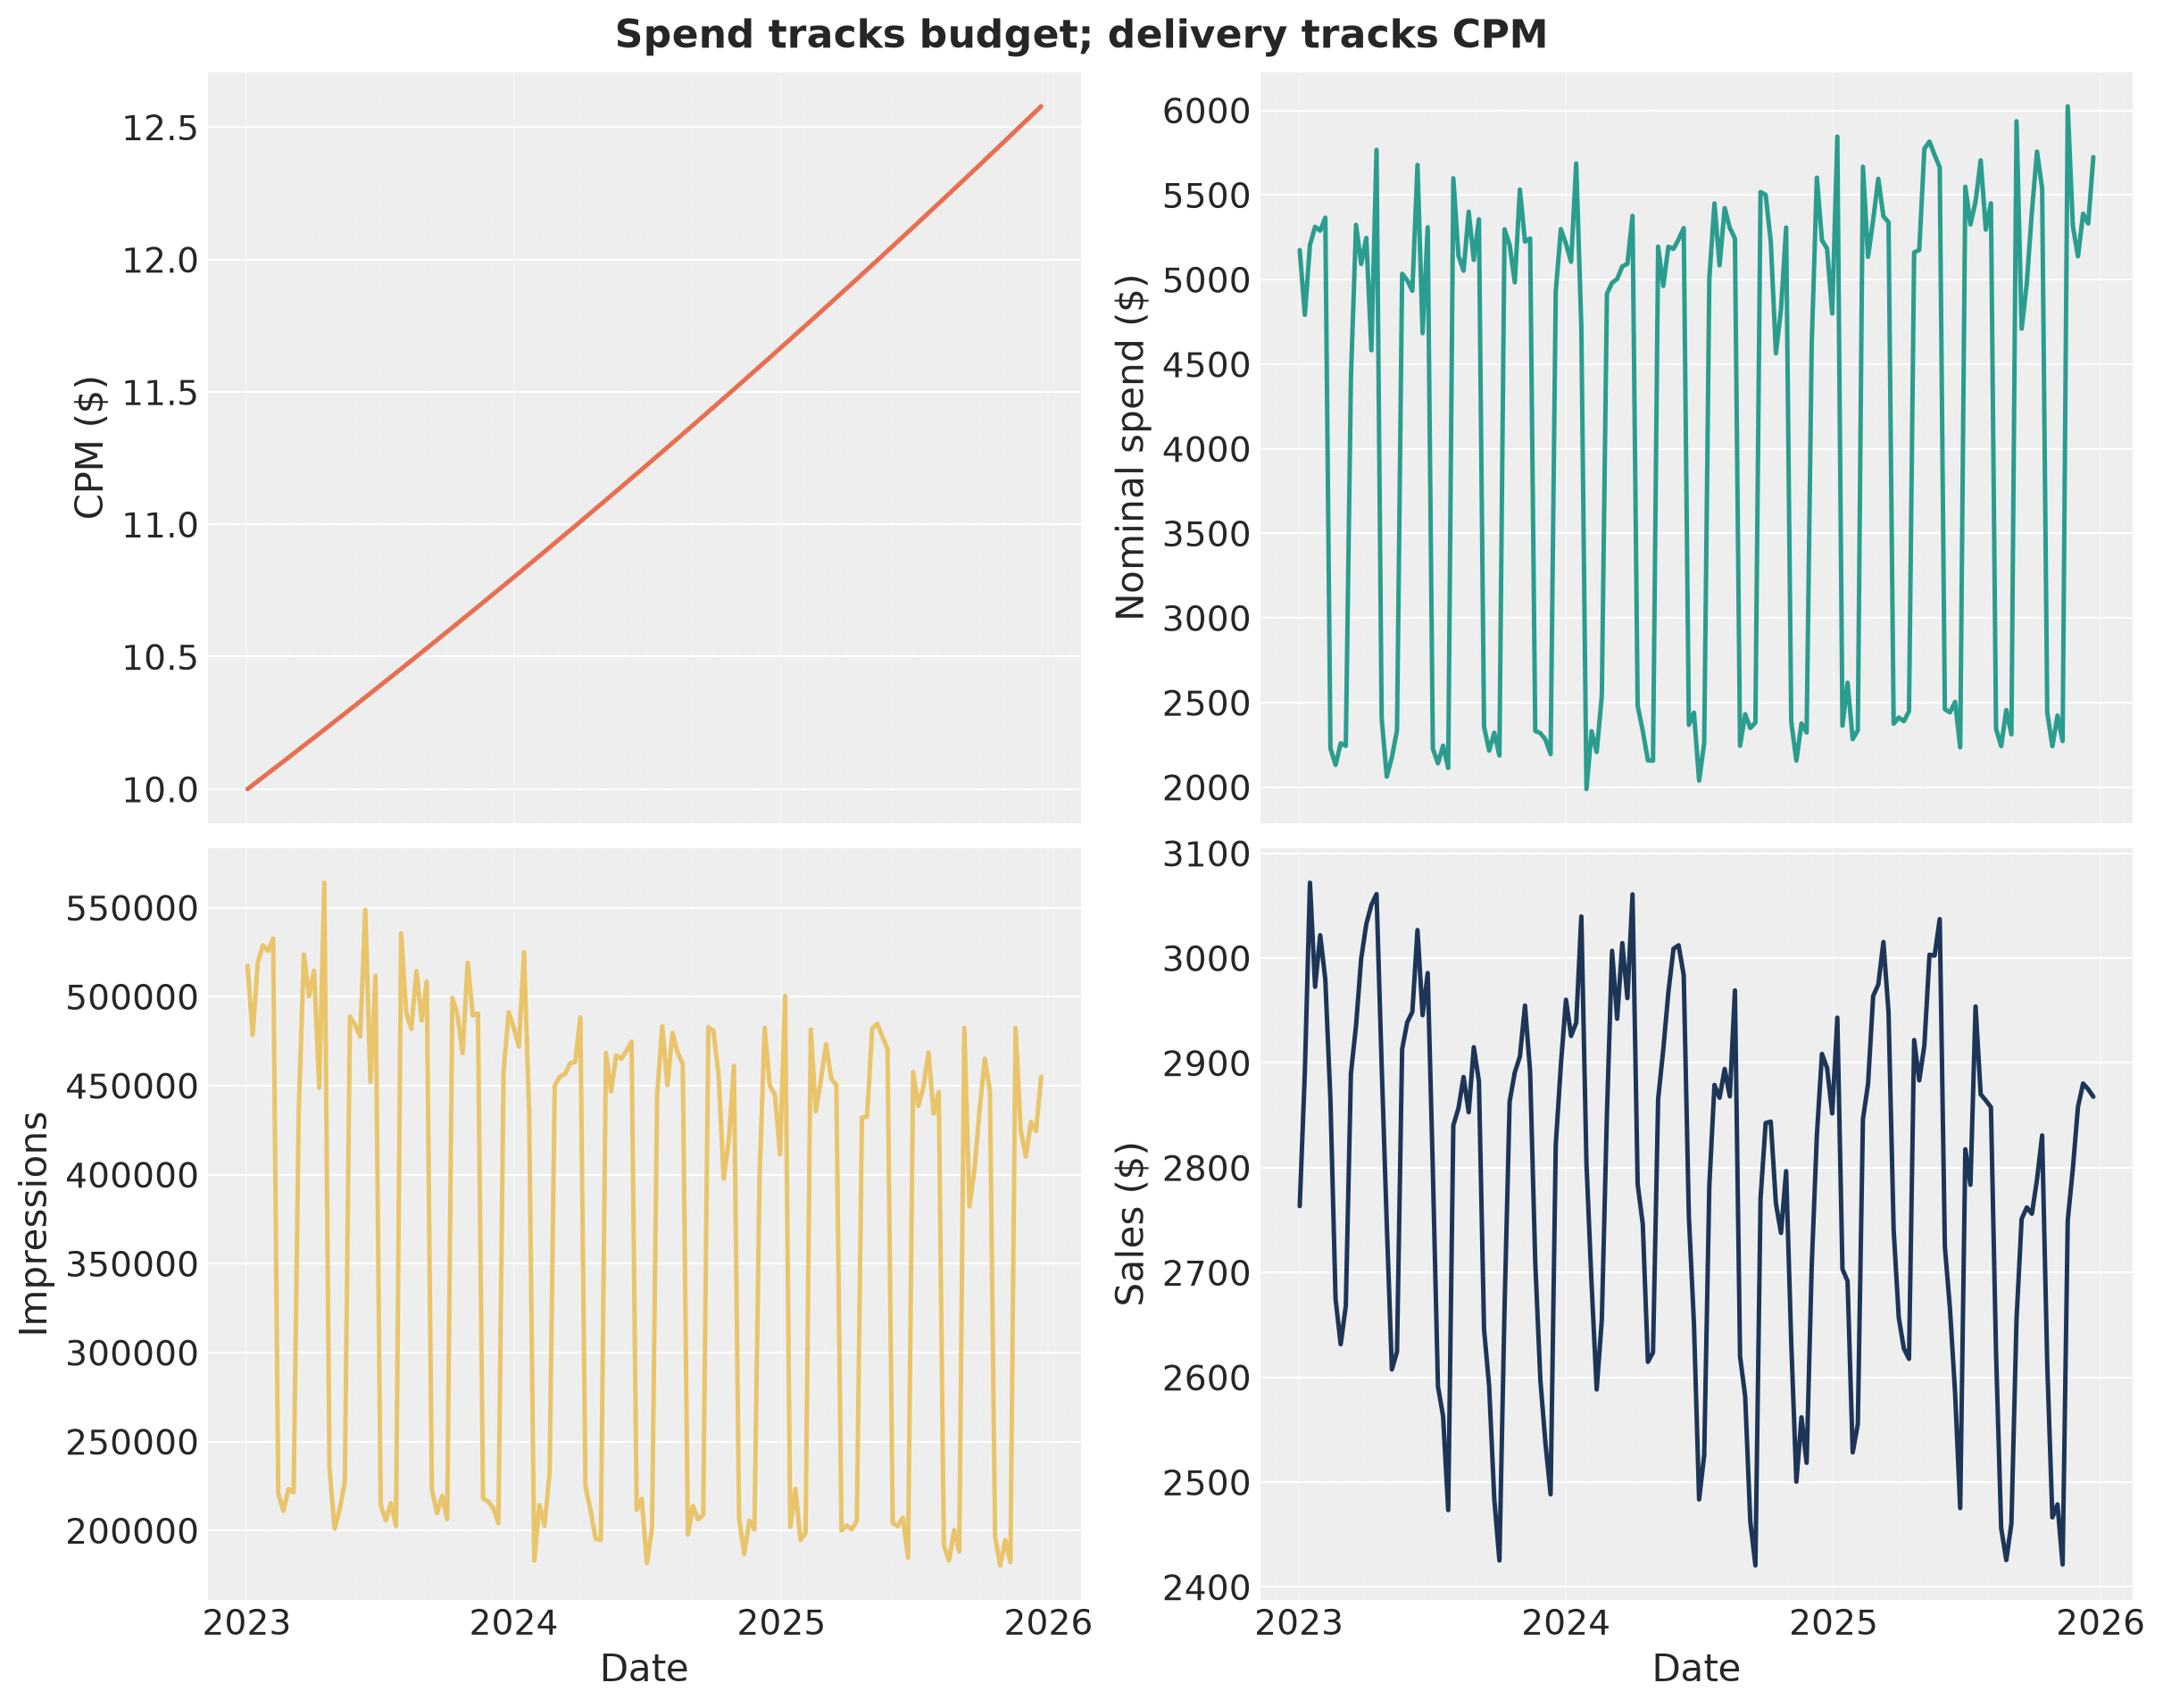

In [6]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(FIG_WIDTH, FIG_HEIGHT * 1.35),
    sharex=True,
)

series = [
    (axes[0, 0], "cpm", "CPM ($)", COLOR_CPM),
    (axes[0, 1], CHANNEL, "Nominal spend ($)", COLOR_SPEND),
    (axes[1, 0], "impressions", "Impressions", COLOR_IMPRESSIONS),
    (axes[1, 1], "y", "Sales ($)", COLOR_Y),
]
for ax, col, ylabel, color in series:
    ax.plot(df["date"], df[col], color=color, linewidth=1.8)
    ax.set_ylabel(ylabel)
    style_date_axis(ax)

axes[1, 0].set_xlabel("Date")
axes[1, 1].set_xlabel("Date")
fig.suptitle("Spend tracks budget; delivery tracks CPM", fontsize=16, fontweight="bold")
plt.show()

**Caption:** Weekly CPM ($), nominal paid-social spend ($), impressions, and sales over 156 weeks. CPM increases faster than spend, impressions decrease, and sales remain approximately stable apart from campaign flighting, seasonality, and noise.


## Deflate spend and fit the MMM

Saturation maps the media input to contribution. If that input is nominal spend, the model treats a nominal ad dollar in 2023 as equivalent to a nominal ad dollar today. When media prices rise, those two amounts can buy different amounts of delivery.

We convert historical spend to today's dollars, where today means the last date in the sample:

$$
I_t = \frac{p_t}{p_{\text{today}}}, \qquad x^{\text{today}}_t = \frac{x^{\text{nom}}_t}{I_t}.
$$

Here $I_t$ is a smooth media-cost index built from an assumed annual inflation rate. In production, that rate is an estimate from platform-reported CPM, aggregated auction data, or agency or industry benchmarks — not from CPI.

We fit the same MMM specification at three assumed annual rates:

| Assumed rate | Role |
| --- | --- |
| **0%** | Nominal spend — no deflation |
| **8%** | Exact simulated benchmark — best case when the index matches truth |
| **16%** | Illustrative over-correction — sensitivity when the index is set too high |

The 8% rate is known only because this is simulated data.

```{important}
Calling {meth}`~pymc_marketing.mmm.mmm.MMM.set_cost_per_unit` on an already-fitted spend model only changes the denominator used for ROAS (return on ad spend). It does not rewrite the media input, so it cannot fix attribution. Deflate spend, or switch to a delivery-based media input that matches your workflow, *before* `fit`. For reporting and optimisation after fitting on delivery units, see {ref}`mmm_cost_per_unit`.
```


We wrap the shared `MMM` specification in a helper so every inflation scenario uses identical model structure.

In [7]:
def fit_mmm(X: pd.DataFrame, y: pd.Series) -> MMM:
    mmm = MMM(
        date_column="date",
        channel_columns=[CHANNEL],
        target_column="y",
        adstock=GeometricAdstock(l_max=8),
        saturation=LogisticSaturation(),
        yearly_seasonality=2,
    )
    mmm.add_mu_effect(
        LinearTrendEffect(
            trend=LinearTrend(n_changepoints=3),
            prefix="trend",
        )
    )
    mmm.build_model(X, y)
    mmm.add_original_scale_contribution_variable(var=["y"])
    mmm.fit(X, y, **FIT_KWARGS)
    return mmm

These functions implement the media-cost index and deflation formula from above.

In [8]:
def mean_by_year(da, dates: pd.Series) -> pd.Series:
    s = da.mean(("chain", "draw")).to_series()
    s.index = pd.to_datetime(dates.to_numpy())
    return s.groupby(s.index.year).mean()


def media_cost_index(annual_rate: float) -> np.ndarray:
    return (1.0 + annual_rate) ** (years_elapsed - years_elapsed[-1])


def deflate_spend(annual_rate: float, X_nominal: pd.DataFrame) -> pd.DataFrame:
    out = X_nominal.copy()
    out[CHANNEL] = X_nominal[CHANNEL] / media_cost_index(annual_rate)
    return out

In [9]:
def _sample_dim(da):
    if "sample" in da.dims:
        return "sample"
    return ("chain", "draw")


def plot_posterior_band(
    ax, dates, da, color, label, alpha=0.3, linewidth=2.5, line_alpha=1.0
):
    sample_dim = _sample_dim(da)
    hdi = az.hdi(da, prob=0.94, dim=sample_dim)
    ax.fill_between(
        dates,
        np.asarray(hdi.sel(ci_bound="lower")).squeeze(),
        np.asarray(hdi.sel(ci_bound="upper")).squeeze(),
        color=color,
        alpha=alpha,
        zorder=1,
    )
    ax.plot(
        dates,
        da.mean(sample_dim).to_numpy().squeeze(),
        color=color,
        linewidth=linewidth,
        alpha=line_alpha,
        label=label,
        zorder=3,
    )


def plot_media_vs_trend(ds, dates, media_true, ylim_media, ylim_trend, title):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 1.35),
        sharex=True,
    )
    plot_posterior_band(axes[0], dates, ds[CHANNEL], COLOR_MEDIA, "Fitted media")
    axes[0].plot(
        dates,
        media_true,
        color="black",
        linestyle="--",
        linewidth=2.0,
        label="True media",
        zorder=5,
    )
    axes[0].set_ylabel("Media contribution ($)")
    axes[0].legend(loc="upper left", **LEGEND_KW)
    axes[0].set_ylim(ylim_media)

    plot_posterior_band(axes[1], dates, ds["trend_effect"], COLOR_TREND, "Fitted trend")
    axes[1].axhline(
        0.0,
        color="black",
        linestyle="--",
        linewidth=2.0,
        label="True trend (0)",
        zorder=5,
    )
    axes[1].set_ylabel("Trend contribution ($)")
    axes[1].set_xlabel("Date")
    axes[1].legend(loc="upper left", **LEGEND_KW)
    axes[1].set_ylim(ylim_trend)
    style_date_axis(axes[1])

    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.show()

Fit one model per assumed inflation rate and store contribution datasets for comparison.

In [10]:
ASSUMED_INFLATION_RATES = {
    0.0: "Nominal spend (0%)",
    ANNUAL_CPM_INFLATION: "8% (simulated truth)",
    HIGH_DEFLATION_RATE: "16% (illustrative high)",
}

X_nominal = df[["date", CHANNEL]].copy()
fits = {}
datasets = {}

for rate in ASSUMED_INFLATION_RATES:
    X_rate = deflate_spend(rate, X_nominal)
    mmm = fit_mmm(X_rate, df["y"])
    fits[rate] = mmm
    datasets[rate] = mmm.compute_counterfactual_contributions_dataset()

mmm_nominal = fits[0.0]
ds_nominal = datasets[0.0]
mmm_today = fits[ANNUAL_CPM_INFLATION]
ds_today = datasets[ANNUAL_CPM_INFLATION]
mmm_high = fits[HIGH_DEFLATION_RATE]
ds_high = datasets[HIGH_DEFLATION_RATE]
X_today = deflate_spend(ANNUAL_CPM_INFLATION, X_nominal)

NUTS[nutpie]: [y_sigma, delta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

NUTS[nutpie]: [y_sigma, delta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

NUTS[nutpie]: [y_sigma, delta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

### Nominal spend shows the failure mode

Contributions are on the original scale of $y$, via {meth}`~pymc_marketing.mmm.mmm.MMM.compute_counterfactual_contributions_dataset`. The black dashed line is the planted media contribution (gentle decline with delivery; flighting visible week to week), not a model output.


Plot fitted media and trend contributions from the nominal-spend model against the simulated reference.

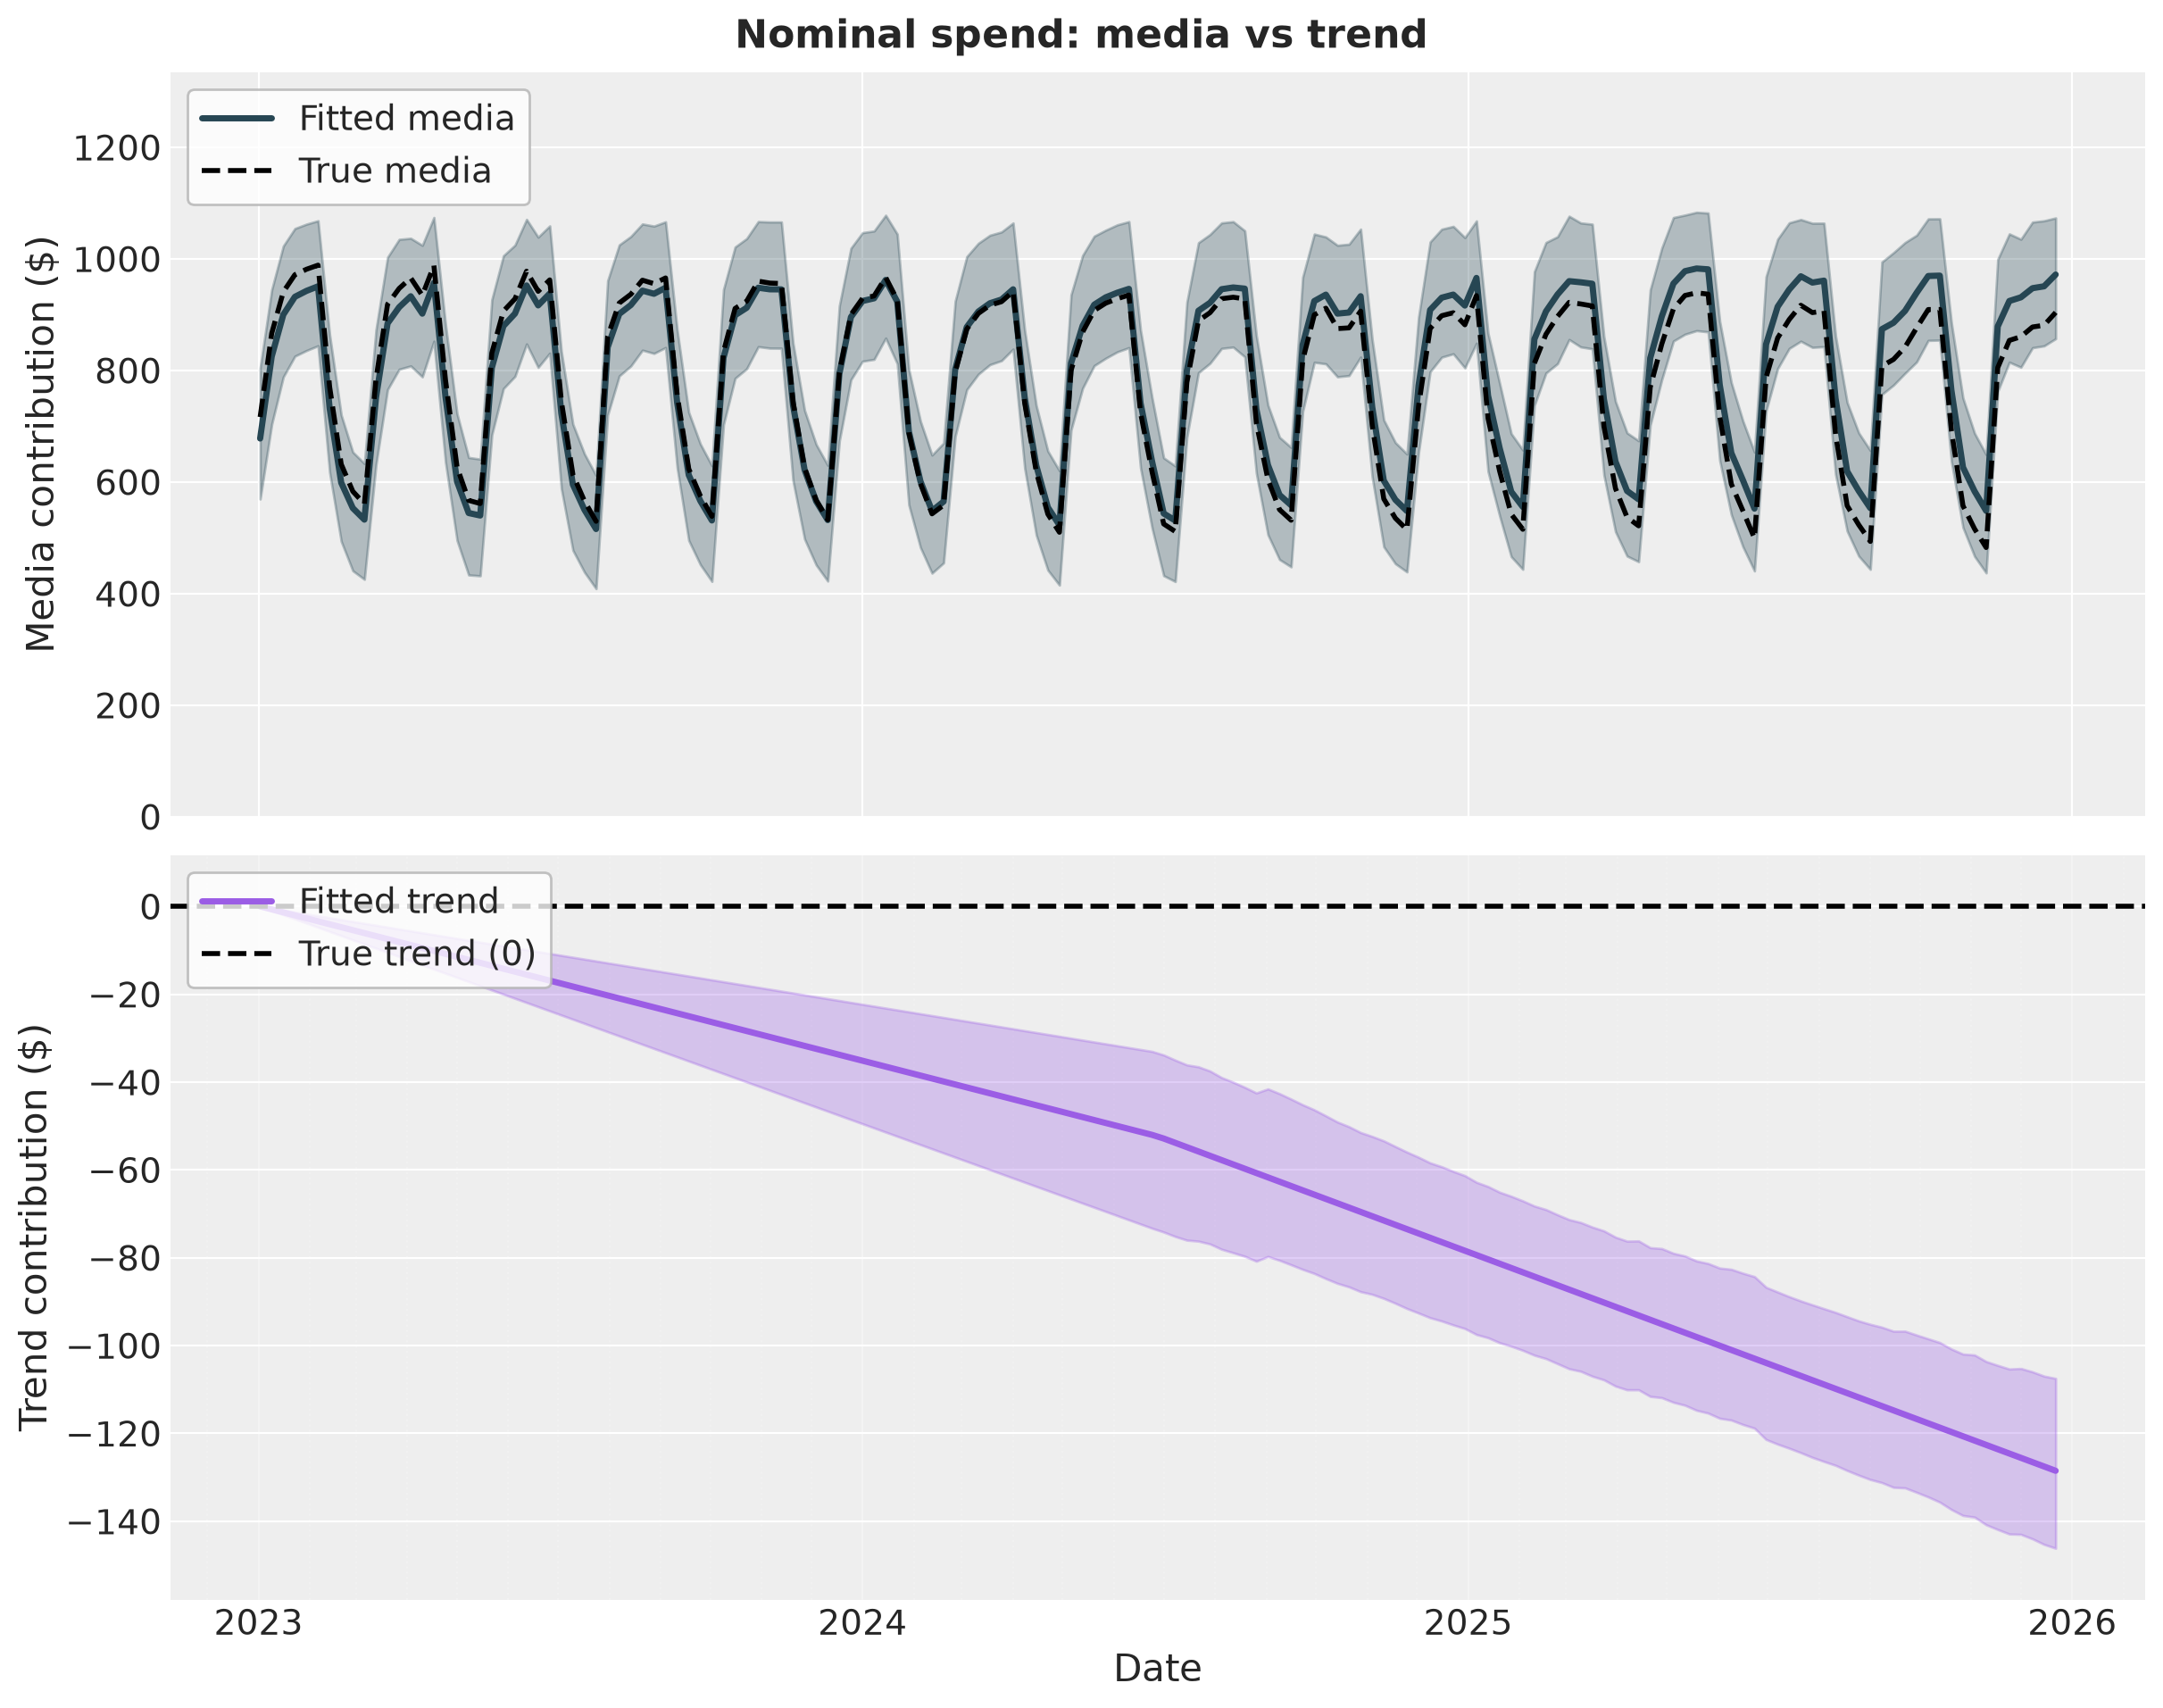

In [11]:
hdi_media = az.hdi(ds_nominal[CHANNEL], prob=0.94)
hdi_trend = az.hdi(ds_nominal["trend_effect"], prob=0.94)
ylim_media = (
    0.0,
    max(
        float(np.asarray(hdi_media.sel(ci_bound="upper")).max()),
        1.25 * float(df["media_true"].max()),
    ),
)
pad_media = 0.08 * ylim_media[1]
ylim_media = (0.0, ylim_media[1] + pad_media)

ylim_trend = (
    min(float(np.asarray(hdi_trend.sel(ci_bound="lower")).min()), 0.0),
    max(float(np.asarray(hdi_trend.sel(ci_bound="upper")).max()), 0.0),
)
pad_trend = 0.08 * (ylim_trend[1] - ylim_trend[0])
ylim_trend = (ylim_trend[0] - pad_trend, ylim_trend[1] + pad_trend)

plot_media_vs_trend(
    ds_nominal,
    df["date"],
    df["media_true"],
    ylim_media,
    ylim_trend,
    title="Nominal spend: media vs trend",
)

**Caption:** Posterior mean and 94% highest-density interval (HDI) for paid-social media contribution (top) and model-implied `LinearTrend` contribution (bottom) when the MMM is fit on nominal spend. Black dashed lines show the simulated reference media contribution and the reference trend of zero.


Later weeks have higher nominal spend but fewer impressions. A time-invariant saturation curve maps the increasing dollars to an increasing fitted media contribution, even though the reference media contribution falls with delivery. Because total sales remain roughly flat, the model-implied trend contribution falls to offset the media contribution.

The declining trend is therefore not observed declining baseline sales. It is the model's decomposition of stable sales when the media input has not been adjusted for inflation.


### Compare index assumptions

The three fits share the same model specification — saturation, seasonality, trend, and sales data. Only the assumed inflation rate — and therefore the units of the media input — change. A good in-sample fit does not establish that the model recovered the correct mechanism; compare trajectories and posterior predictive bands, not only averages.


Draw posterior predictive samples for the nominal-spend and exact-index models to check whether comparable fits imply the same decomposition.

In [12]:
pp_nominal = mmm_nominal.sample_posterior_predictive(
    X_nominal, extend_idata=False, random_seed=RANDOM_SEED
)
pp_today = mmm_today.sample_posterior_predictive(
    X_today, extend_idata=False, random_seed=RANDOM_SEED
)

Sampling: [y]


Output()

Sampling: [y]


Output()

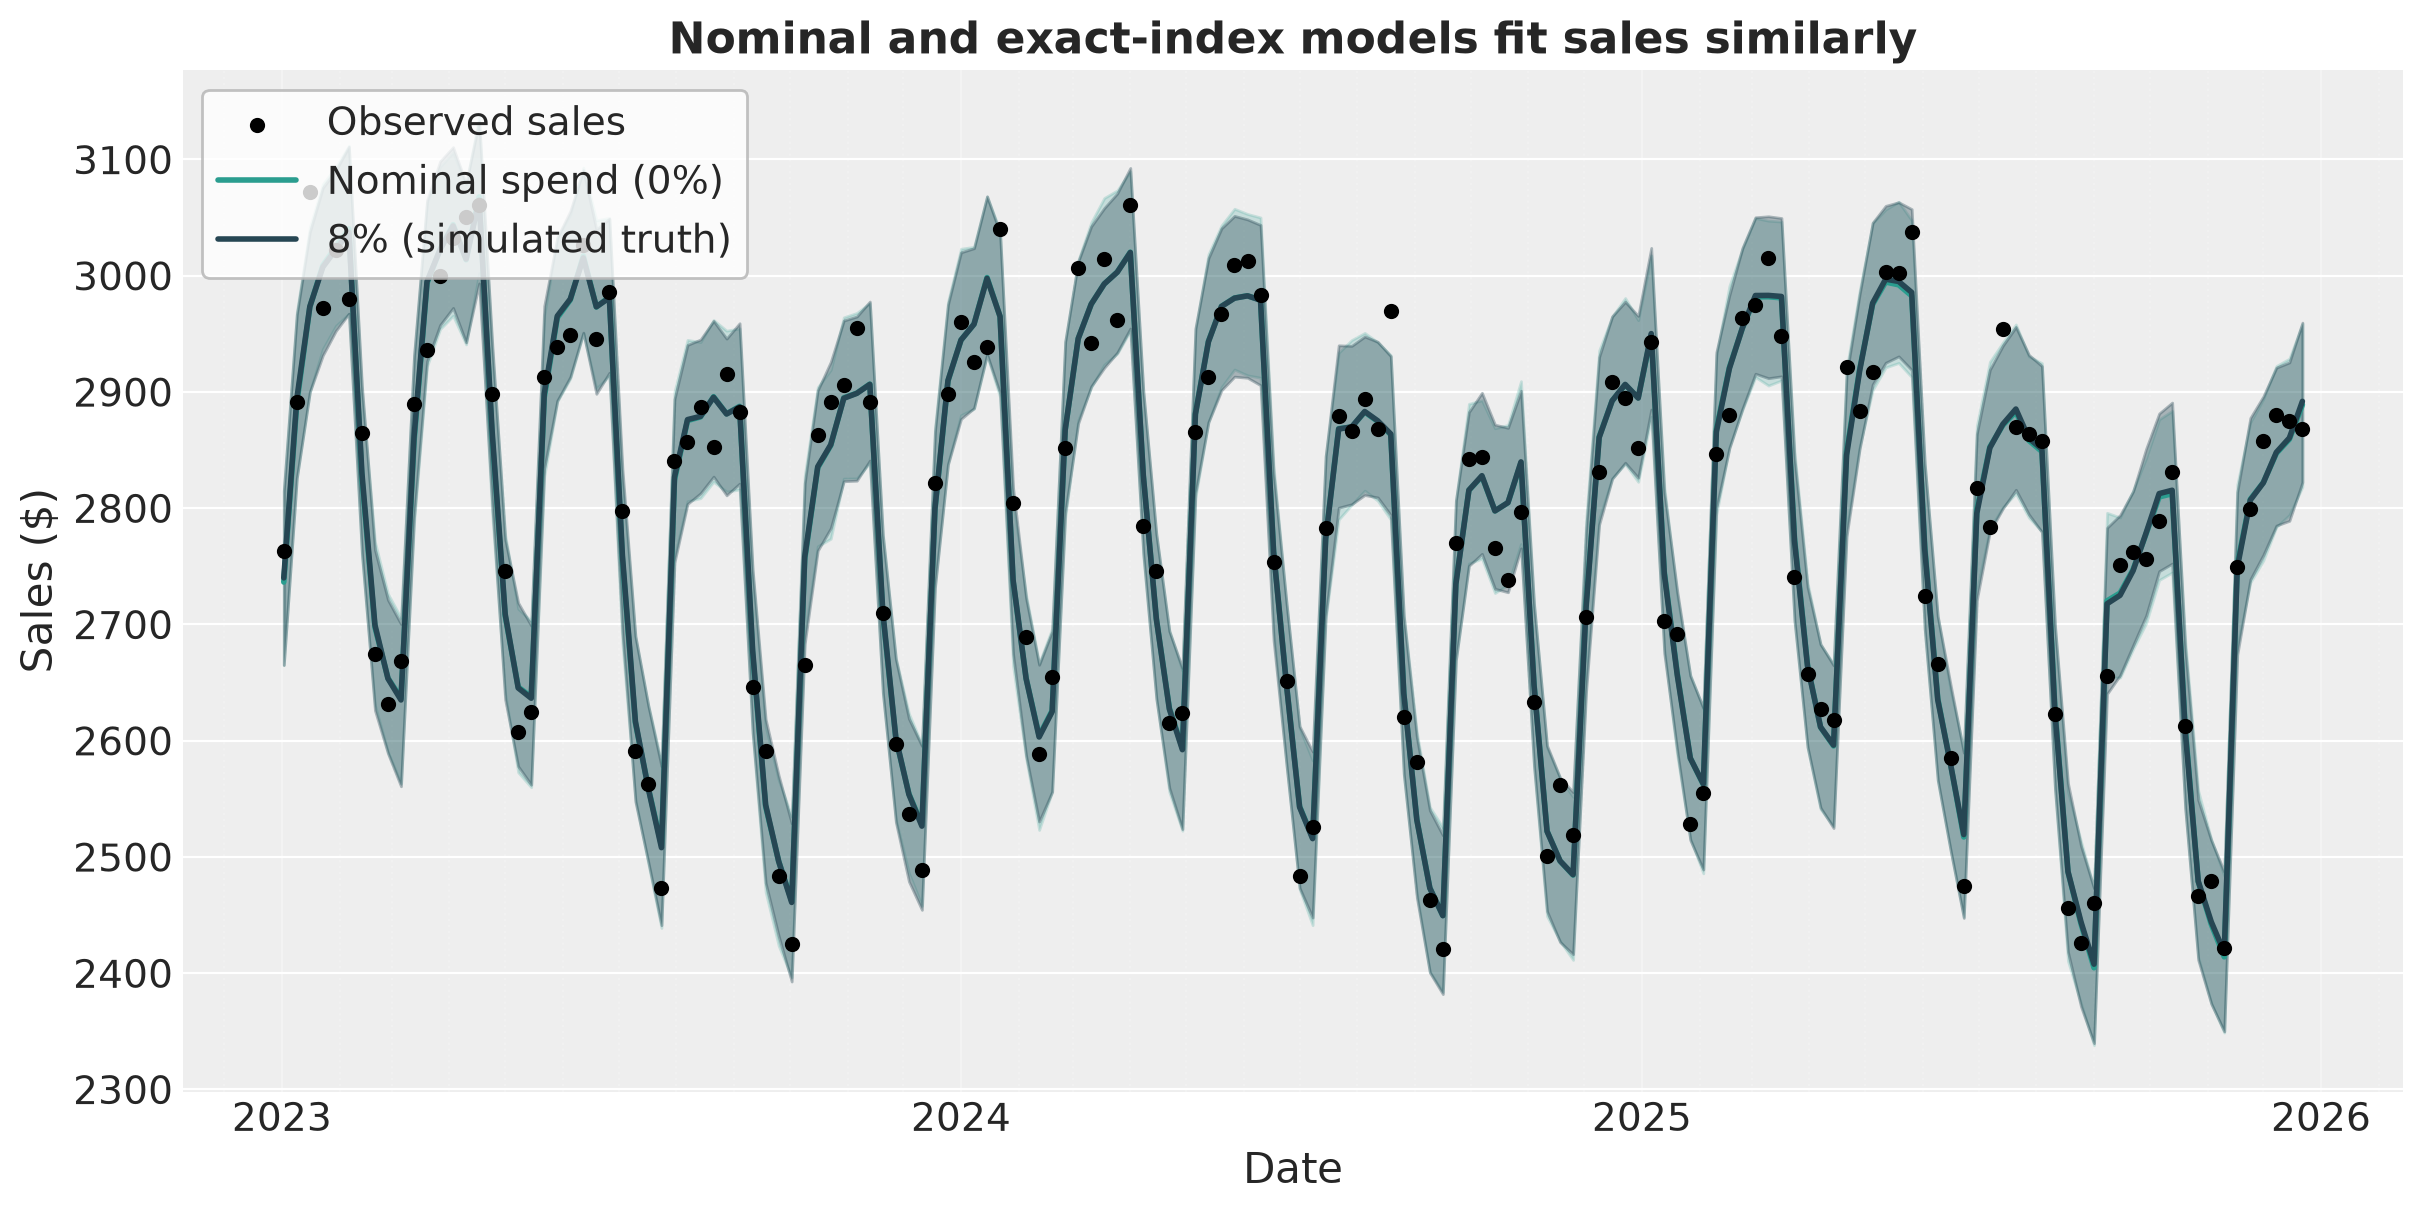

In [13]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT * 0.85))
ax.scatter(
    df["date"],
    df["y"],
    color="black",
    s=20,
    marker="o",
    label="Observed sales",
    zorder=4,
)
for pp, label, color, alpha in [
    (pp_nominal, "Nominal spend (0%)", COLOR_SPEND, 0.2),
    (pp_today, "8% (simulated truth)", COLOR_MEDIA, 0.35),
]:
    y_pp = pp["y_original_scale"]
    plot_posterior_band(ax, df["date"], y_pp, color, label, alpha=alpha, linewidth=2.0)
style_date_axis(ax)
ax.set_ylabel("Sales ($)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", **LEGEND_KW)
ax.set_title(
    "Nominal and exact-index models fit sales similarly",
    fontsize=16,
    fontweight="bold",
)
plt.show()

**Caption:** Observed weekly sales ($) with posterior predictive mean and 94% HDI from the nominal-spend and exact 8% index models. Overlapping bands show that comparable in-sample fit does not identify the correct media-versus-trend split.


Overlay model-implied trend contributions from all three index assumptions.

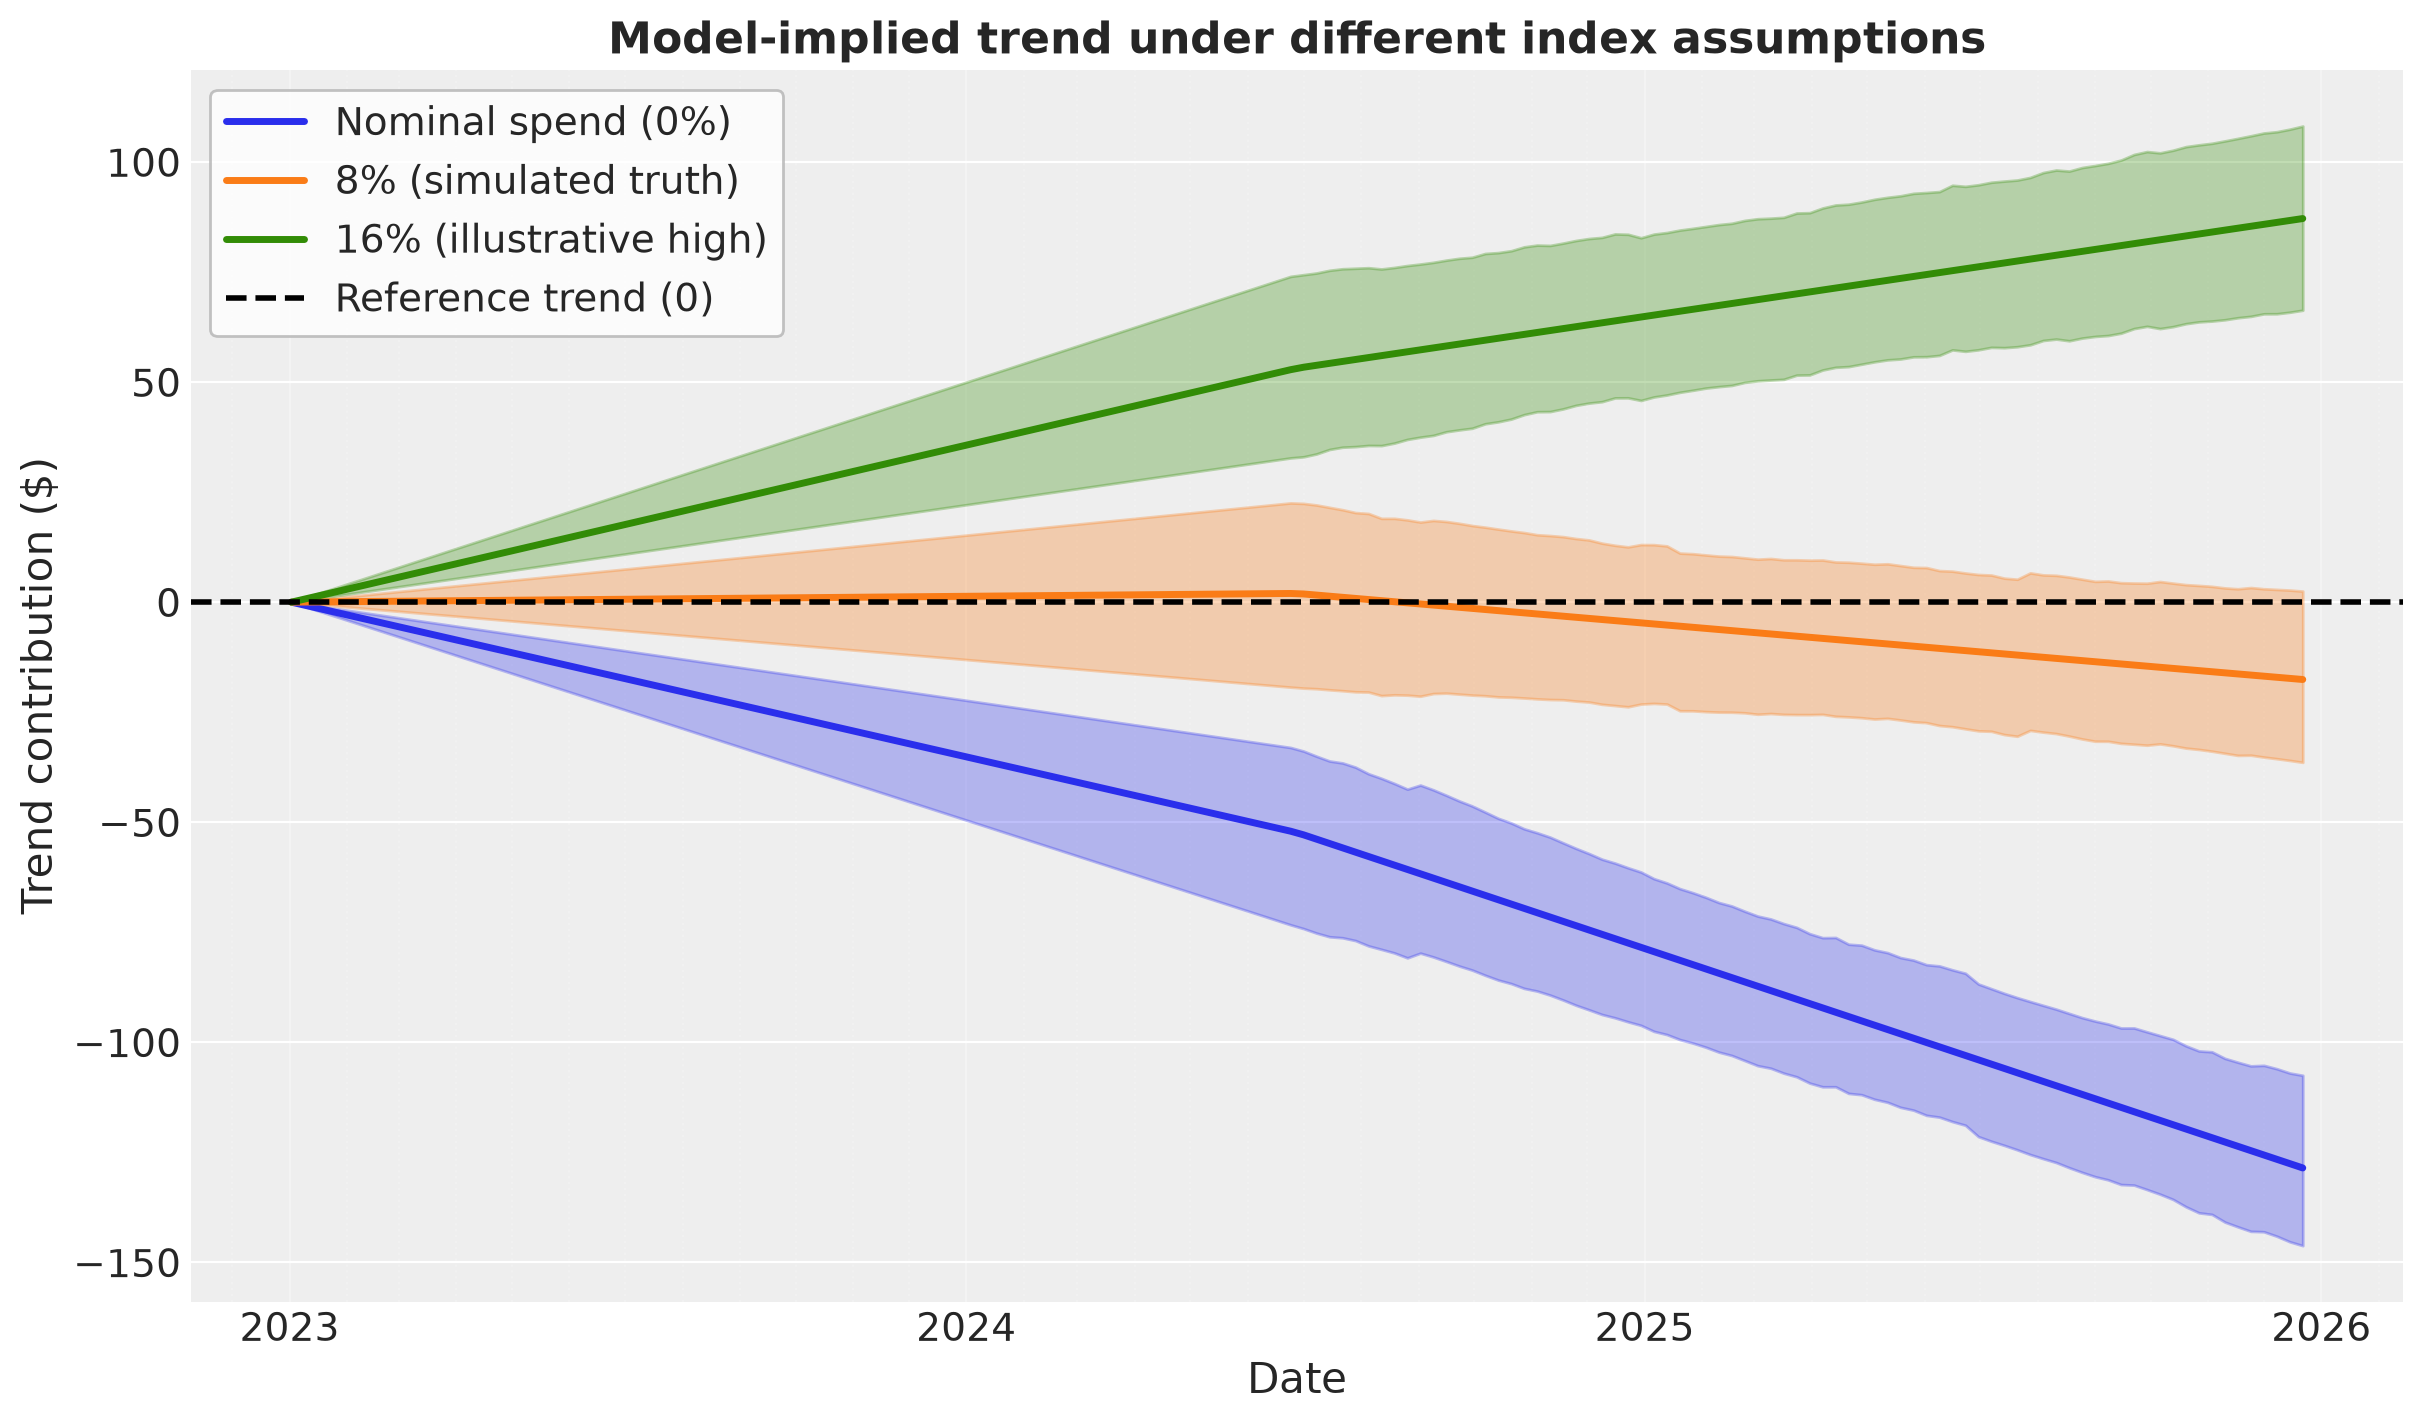

In [14]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

variants = [
    (ds_nominal, "Nominal spend (0%)", "C0"),
    (ds_today, "8% (simulated truth)", "C1"),
    (ds_high, "16% (illustrative high)", "C2"),
]
for ds, label, color in variants:
    plot_posterior_band(ax, df["date"], ds["trend_effect"], color, label)

ax.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=2.0,
    label="Reference trend (0)",
    zorder=5,
)
ax.set_ylabel("Trend contribution ($)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", **LEGEND_KW)
ax.set_title(
    "Model-implied trend under different index assumptions",
    fontsize=16,
    fontweight="bold",
)
style_date_axis(ax)
plt.show()

**Caption:** Posterior mean and 94% HDI for model-implied trend contribution at 0%, 8%, and illustrative 16% assumed annual inflation. The black dashed horizontal line shows the simulated reference trend of zero.


The table summarizes mean weekly contributions by year across the three assumed inflation rates. With nominal spend (0%), the model-implied media contribution increases while the reference media contribution decreases, and the model-implied trend becomes more negative to offset that difference.

At the exact 8% benchmark, the media trajectory moves toward the reference delivery pattern and the trend contribution is smaller. With too much deflation (16%), the trend correction overshoots. The average media contribution can still look plausible under the wrong index, so trajectories matter more than levels alone.


In [15]:
years = df["date"].dt.year
comparison = pd.DataFrame(
    {
        "true_media": df.groupby(years)["media_true"].mean(),
        "media_0pct": mean_by_year(ds_nominal[CHANNEL], df["date"]),
        "trend_0pct": mean_by_year(ds_nominal["trend_effect"], df["date"]),
        "media_8pct": mean_by_year(ds_today[CHANNEL], df["date"]),
        "trend_8pct": mean_by_year(ds_today["trend_effect"], df["date"]),
        "media_16pct": mean_by_year(ds_high[CHANNEL], df["date"]),
        "trend_16pct": mean_by_year(ds_high["trend_effect"], df["date"]),
    }
)
comparison.index.name = "year"
comparison.round(1)

,true_media,media_0pct,trend_0pct,media_8pct,trend_8pct,media_16pct,trend_16pct
year,,,,,,,
2023,805.5,783.7,-17.2,819.8,0.7,857.0,17.5
2024,779.2,795.9,-54.8,794.2,0.1,796.5,51.8
2025,761.1,815.5,-104.0,776.4,-11.3,743.1,76.2


## Summary and practical guidance

There is no single right media input for every channel. The table below lists common workflows rather than universal rules.

| Situation | Common MMM input | Notes |
| --- | --- | --- |
| Impressions or GRPs are available | Often fit delivery units directly | Puts saturation on a stable exposure measure when delivery is well measured. Tradeoffs include data quality, missing channels, and whether the estimand is budget or exposure; see {ref}`mmm_cost_per_unit`. |
| Spend and CPM or cost-per-GRP are available | Often reconstruct delivery before fitting | Uses a delivery measure while retaining observed cost information for reporting. |
| Spend only | Deflate spend with a smooth external media-cost index before `fit` | Makes historical currency values more comparable when media prices changed. Treat the index as an estimate and run sensitivity on the assumed rate. |
| The question is specifically about budget or cost dynamics | Model spend deliberately, with a clearly stated estimand | Different use case from estimating media exposure; may require an explicit cost or delivery model. |

Use a media-cost index, not consumer-price inflation (CPI). Deflation here is meant to put historical spend into comparable *media-price* units. CPI tracks a basket of consumer goods, not the cost of buying ads, and media prices typically move at a different rate and on a different calendar. Deflating an 8% media-price drift with a ~2% CPI series leaves most of the unit-cost change in $X$, which is close to not deflating.

Prefer an annual or quarterly media-cost index, not a jagged weekly CPM series. Week-to-week cost variation reflects auctions, mix, targeting, and seasonal competition rather than inflation. Dividing spend by that series injects high-frequency noise into the media input, and if the CPM is your own realized cost it is partly endogenous to bidding. If delivery is well measured, fit impressions or GRPs instead of reconstructing them from a noisy cost series.

Do not automatically provide spend and impressions as two independent media channels. Spend is upstream of delivery, so including both requires a separate modelling argument about any direct effect of spend on sales.

**Target scale.** This example keeps sales in nominal dollars because the simulated baseline is flat. If your target is revenue and product prices are also inflating, decide whether the estimand is nominal revenue, real revenue, or unit sales and adjust $y$ or add price controls accordingly. Deflating $X$ while leaving a nominal revenue target unchanged is a deliberate mismatch only when revenue inflation matters.

**Summary.**

- Media inflation can make nominal spend rise while impressions or GRPs fall.
- A nominal-spend MMM may fit stable sales by increasing its media contribution and decreasing its model-implied trend. That declining trend is an inferred decomposition, not observed declining baseline sales.
- Comparable in-sample fit does not verify the correct decomposition; check contribution trajectories and index sensitivity.
- `set_cost_per_unit` changes ROAS denominators after fitting. It does not correct a media input specified in the wrong units.
- For budget optimisation, pass a future `cost_per_unit` to {meth}`~pymc_marketing.mmm.mmm.MMM.optimize_budget` or fit on stable delivery units. See {ref}`mmm_cost_per_unit`.

```{note}
Long-horizon optimisation and scenario planning need planned-horizon cost-per-unit assumptions because future dollars may buy less delivery. That workflow is documented in {ref}`mmm_cost_per_unit`; this notebook stops at attribution preprocessing.
```


In [16]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing

Last updated: Wed, 09 Sep 2026

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.15.0

pymc_marketing: 1.1.0

arviz         : 1.2.0
graphviz      : 0.21
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 2.3.3
pymc_marketing: 1.1.0
pytensor      : 3.2.4

Watermark: 2.6.0

